## Ревью фильтрации hwr200
Плохие (высокий CER → вероятно битая разметка) и хорошие пары. Запусти `scripts/filter_hwr200.py` перед этим.

In [4]:
import json, random
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image

ROOT = Path.cwd()
while not (ROOT / "outputs").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
OUT = ROOT / "outputs" / "hwr200_filtered"
SRC = "hwr200"

def load(split, kind):
    return json.loads((OUT / f"{SRC}_{split}_{kind}.json").read_text(encoding="utf-8"))

def show(recs, title, n=10, seed=0):
    if not recs:
        print(f"{title}: empty"); return
    recs = random.Random(seed).sample(recs, min(n, len(recs)))
    fig, axes = plt.subplots(len(recs), 1, figsize=(12, 1.6 * len(recs)), squeeze=False)
    for ax, r in zip(axes[:, 0], recs):
        ax.imshow(Image.open(r["path"]).convert("RGB")); ax.axis("off")
        ax.set_title(f"cer={r['cer']}   GT: {r['label']}   |   PRED: {r['pred']}", fontsize=9, loc="left")
    fig.suptitle(title); plt.tight_layout(); plt.show()

print(json.loads((OUT / f"{SRC}_filter_report.json").read_text(encoding="utf-8")))

{'source': 'hwr200', 'checkpoint': 'outputs/trocr_small_bi_finetune_without_hwr200/best', 'keep_percentile': 80.0, 'splits': {'train': {'total': 58577, 'good': 46900, 'bad': 11677, 'threshold_cer': 0.2703, 'cer_percentiles': {'p50': 0.15, 'p75': 0.243, 'p90': 0.348, 'p95': 0.429, 'p99': 0.692}}, 'test': {'total': 6508, 'good': 5214, 'bad': 1294, 'threshold_cer': 0.2683, 'cer_percentiles': {'p50': 0.148, 'p75': 0.242, 'p90': 0.342, 'p95': 0.42, 'p99': 0.714}}}}


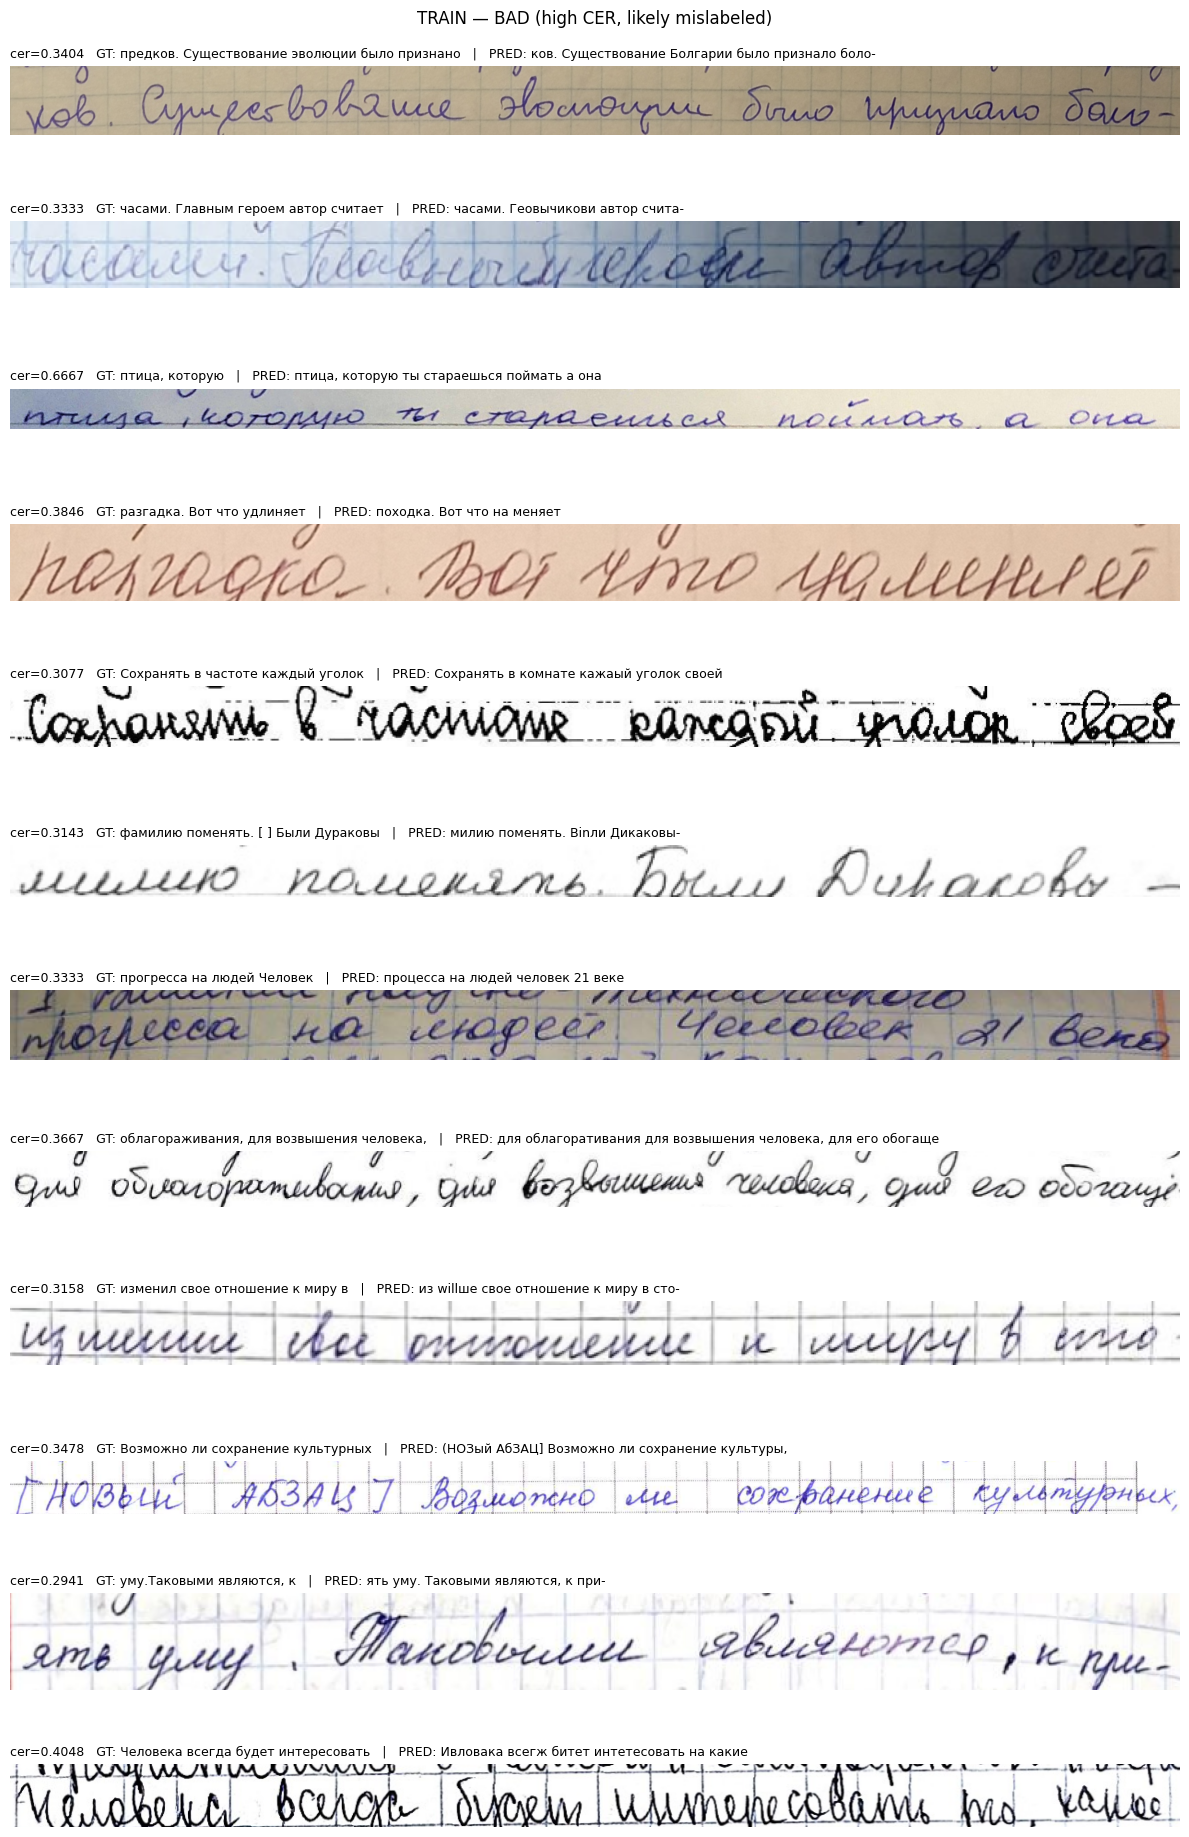

In [5]:
show(load("train", "bad"), "TRAIN — BAD (high CER, likely mislabeled)", n=12)

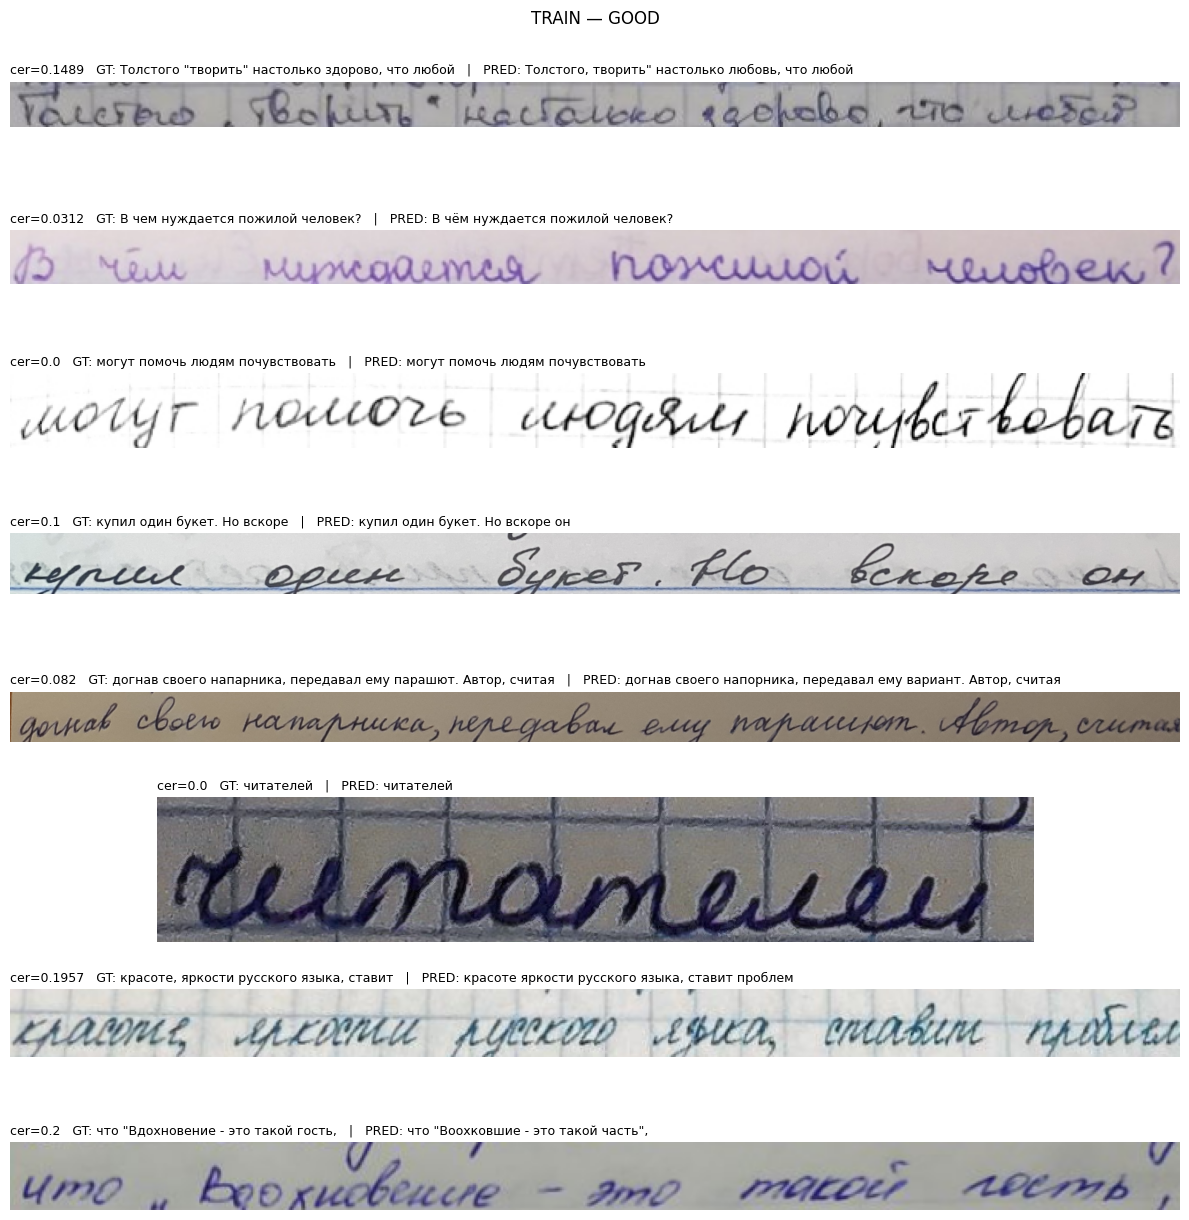

In [6]:
show(load("train", "good"), "TRAIN — GOOD", n=8)

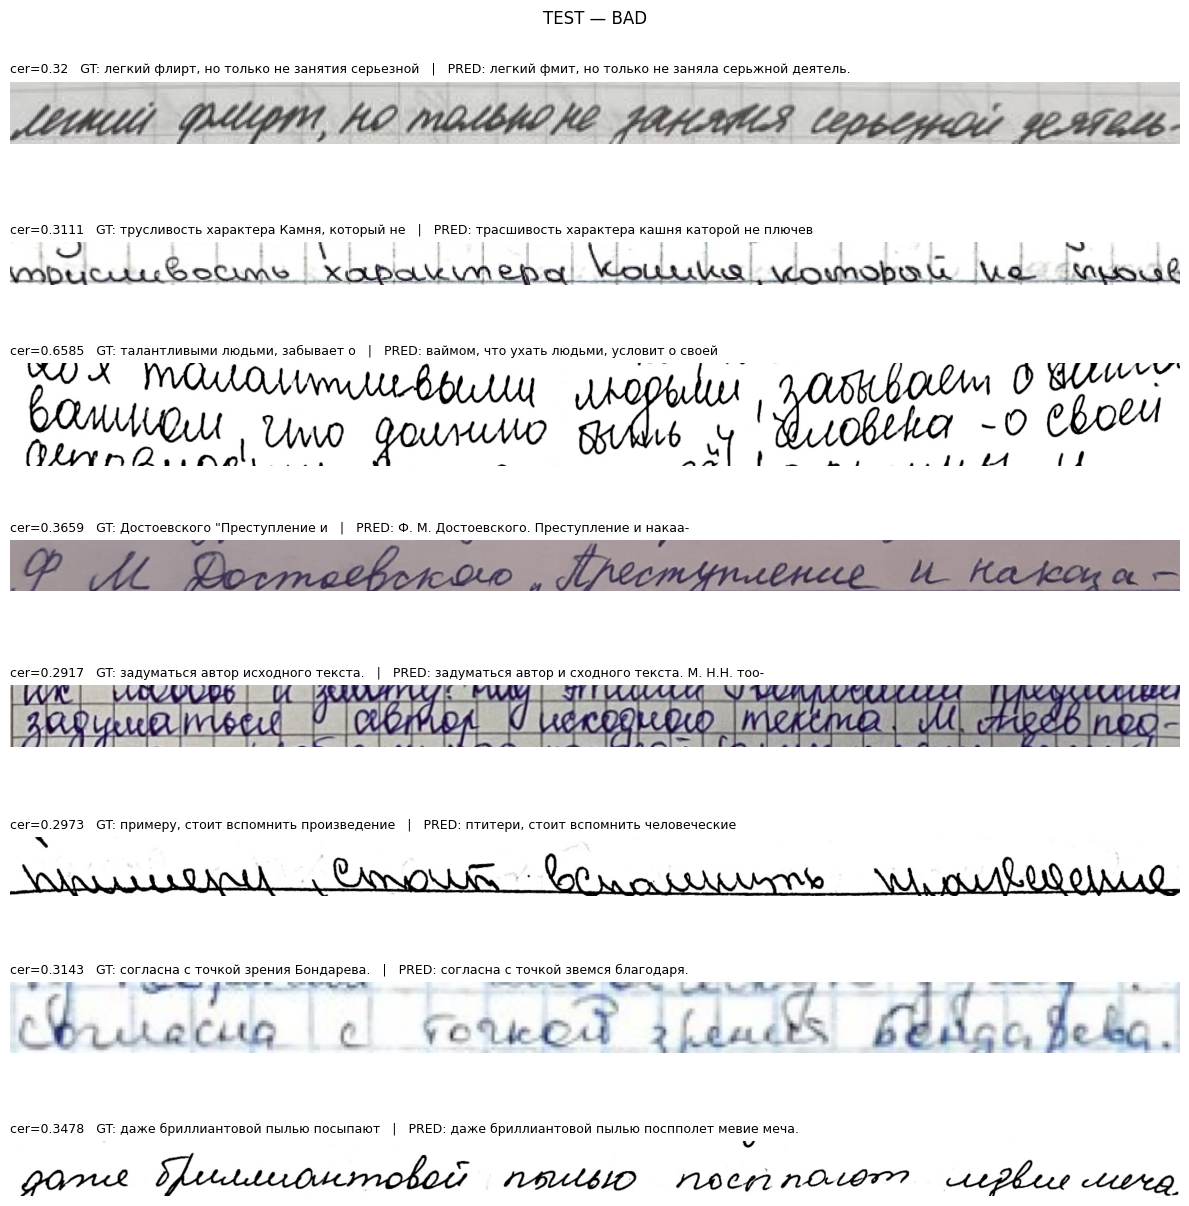

In [7]:
show(load("test", "bad"), "TEST — BAD", n=8)

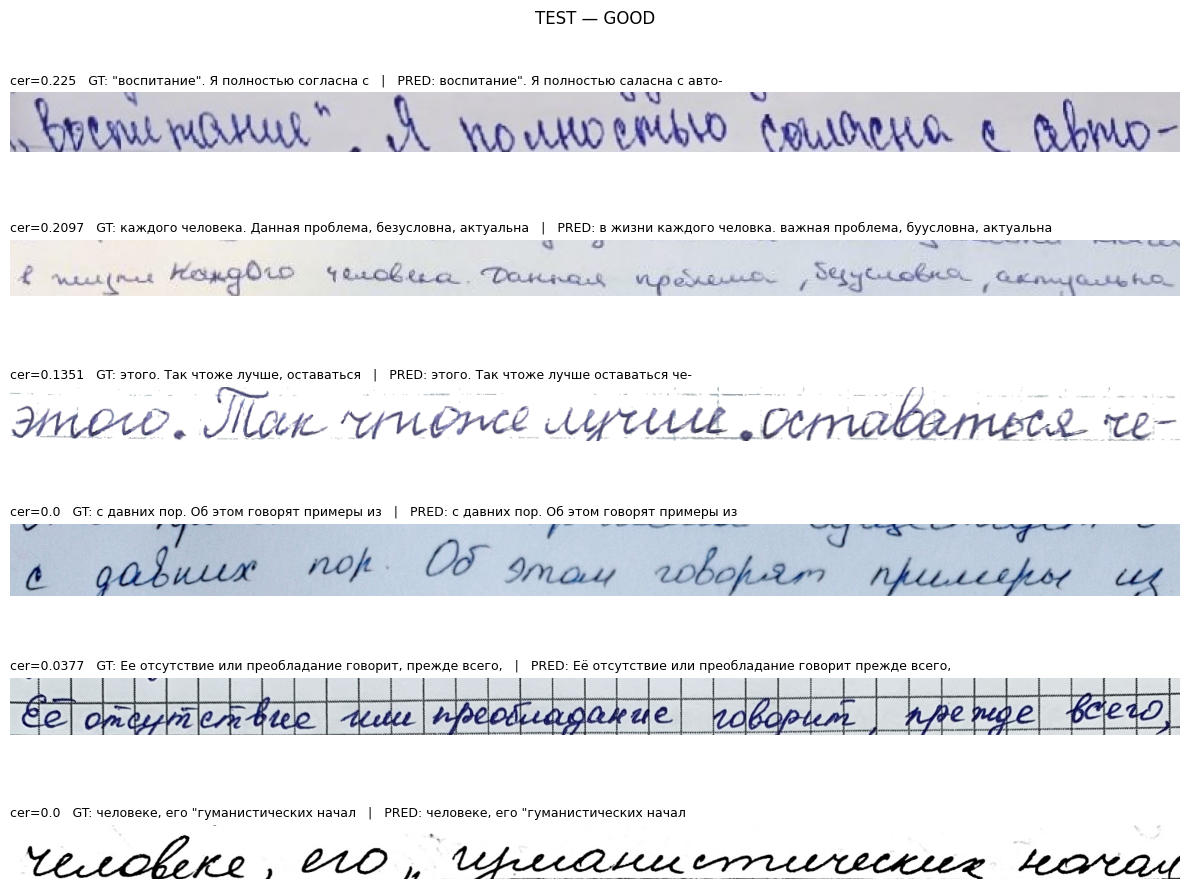

In [8]:
show(load("test", "good"), "TEST — GOOD", n=6)